# PU experiments

In [1]:
import os
import pandas as pd
import numpy as np
from data.datasets import get_pd_dataset,prepare_and_split_data
from data.dataset_helpers import SAR
from config import CONFIG
import matplotlib.pyplot as plt
from classifiers.TM_log_reg import TwoModelLogReg
from classifiers.classic_log_reg import ClassicLogReg
from classifiers.naive_log_reg import NaiveLogReg
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score,classification_report
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans

import seaborn as sns
import numpy.random as rng
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
import warnings
from sklearn.exceptions import ConvergenceWarning
import json

In [2]:
datasets = ["mock","diabetes","breastcancer","mnist"]

In [3]:
models = {
    "classic": ClassicLogReg(),
    "naive": NaiveLogReg(),
    "two_model": TwoModelLogReg()
}

In [4]:
def describe_dataset(data,name):
    print(f"\n \nDataset: {name} \n")
    n_sampels = data.shape[0]
    n_features = data.shape[1]-1    
    class_balance = data["target"].sum()/n_sampels
    print(f"Number of samples: {n_sampels}")
    print(f"Number of features: {n_features}")
    print(f"Class balance (positive class): {class_balance:.2f} \n")
    X_train,X_test,y_train,y_test = train_test_split(data.drop(columns=["target"]), data["target"], test_size=0.2, random_state=42)
    warnings.filterwarnings("ignore", category=ConvergenceWarning)

    clf = LogisticRegression(verbose=0)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(pd.DataFrame(classification_report(y_test, y_pred,output_dict=True)).T)


for dataset in datasets:
    data = get_pd_dataset(name=dataset)
    describe_dataset(data,name=dataset)



 
Dataset: mock 

Number of samples: 3315
Number of features: 4
Class balance (positive class): 0.02 

              precision    recall  f1-score     support
0              0.978852  0.998459  0.988558  649.000000
1              0.000000  0.000000  0.000000   14.000000
accuracy       0.977376  0.977376  0.977376    0.977376
macro avg      0.489426  0.499230  0.494279  663.000000
weighted avg   0.958182  0.977376  0.967684  663.000000

 
Dataset: diabetes 

Number of samples: 768
Number of features: 8
Class balance (positive class): 0.35 

              precision    recall  f1-score     support
0              0.812500  0.787879  0.800000   99.000000
1              0.637931  0.672727  0.654867   55.000000
accuracy       0.746753  0.746753  0.746753    0.746753
macro avg      0.725216  0.730303  0.727434  154.000000
weighted avg   0.750154  0.746753  0.748167  154.000000

 
Dataset: breastcancer 

Number of samples: 569
Number of features: 30
Class balance (positive class): 0.63 

     

# label frequency

In [81]:
path = "/Users/cas/Documents/naive_pu/EXPERIMENTS/c/0.6_mnist_naive_2.pkl"
df = pd.read_pickle(path)
df["accuracy"].unique()
df = df[df["c"]<0.6]
df = df[df["model"]!="oracle"]


In [82]:
mock = df[df["dataset"]=="mock"].copy()
diabetes = df[df["dataset"]=="diabetes"].copy()
breastcancer = df[df["dataset"]=="breastcancer"].copy()
mnist = df[df["dataset"]=="mnist"].copy() 
print(f"Shapes {mock.shape}, {diabetes.shape}, {breastcancer.shape}, {mnist.shape}")  

Shapes (150, 13), (150, 13), (150, 13), (150, 13)


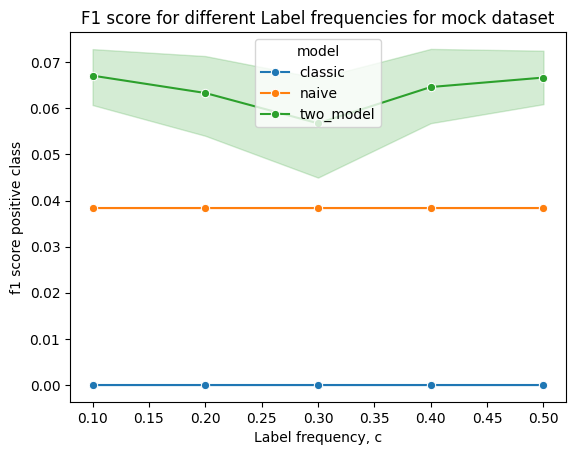

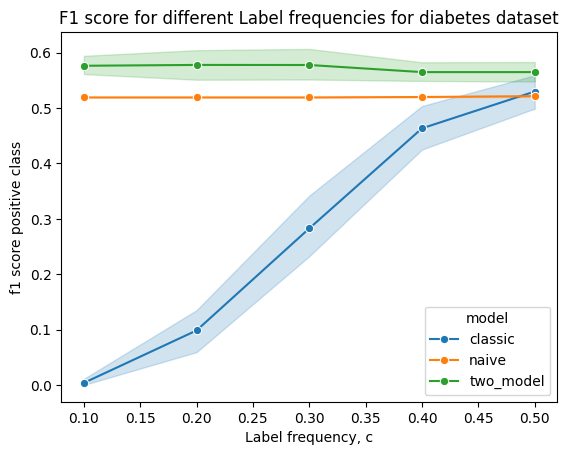

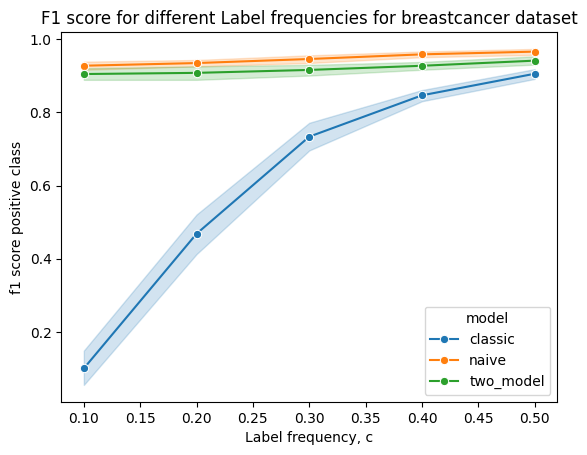

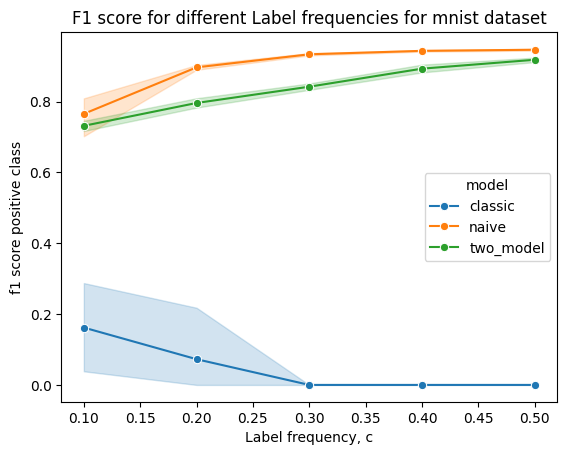

In [86]:


for name,data in zip(datasets,[mock,diabetes,breastcancer,mnist]):
    plt.figure()
    sns.lineplot(data=data, x="c", y="1 f1", hue="model", marker="o")
    plt.title(f"F1 score for different Label frequencies for {name} dataset")
    plt.ylabel(r"f1 score positive class")
    plt.xlabel("Label frequency, c")
    plt.savefig(f"graphs/c_{name}_f1.png")
    # sns.lineplot(data=data, x="c", y=1 precision", hue="model", marker="o", linestyle="--")
    # sns.lineplot(data=data, x="c", y="1 recall", hue="model", marker="o", linestyle=":")



In [57]:
mock

,c,dataset,iter,model,accuracy,0 precision,1 precision,0 recall,1 recall,0 f1,1 f1,0 support,1 support
0,0.1,mock,0,classic,0.980392,0.980392,0.000000,1.000000,0.000000,0.990099,0.000000,650,13
1,0.1,mock,0,naive,0.019608,0.000000,0.019608,0.000000,1.000000,0.000000,0.038462,650,13
2,0.1,mock,0,two_model,0.748115,0.985915,0.036145,0.753846,0.461538,0.854403,0.067039,650,13
3,0.1,mock,0,oracle,0.980392,0.980392,0.000000,1.000000,0.000000,0.990099,0.000000,650,13
4,0.1,mock,1,classic,0.980392,0.980392,0.000000,1.000000,0.000000,0.990099,0.000000,650,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1475,1.0,mock,8,oracle,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0
1476,1.0,mock,9,classic,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0
1477,1.0,mock,9,naive,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0
1478,1.0,mock,9,two_model,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0


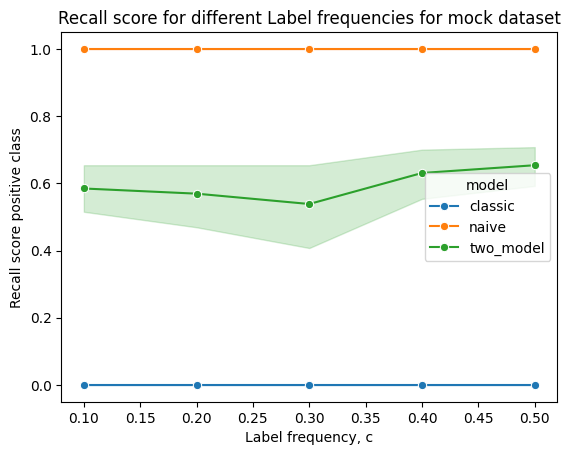

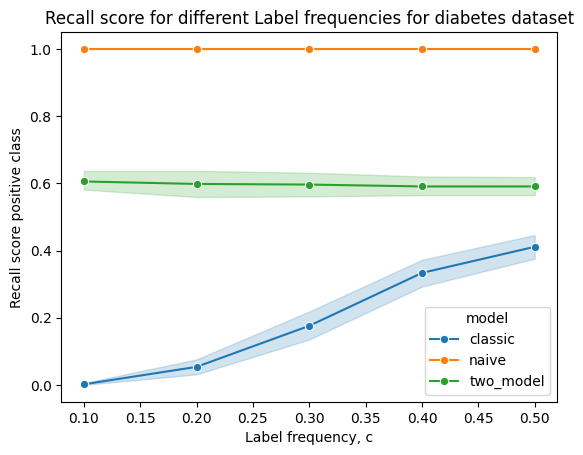

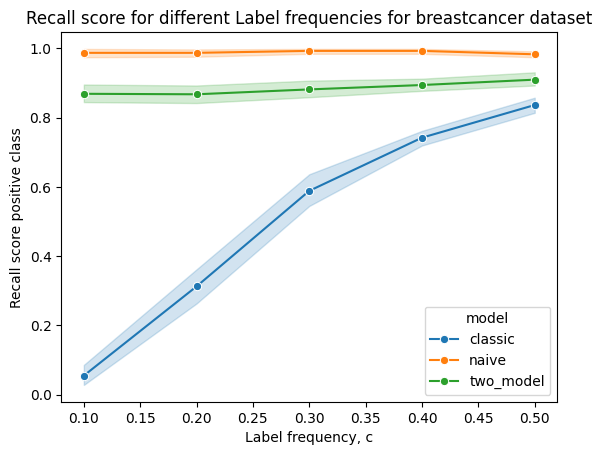

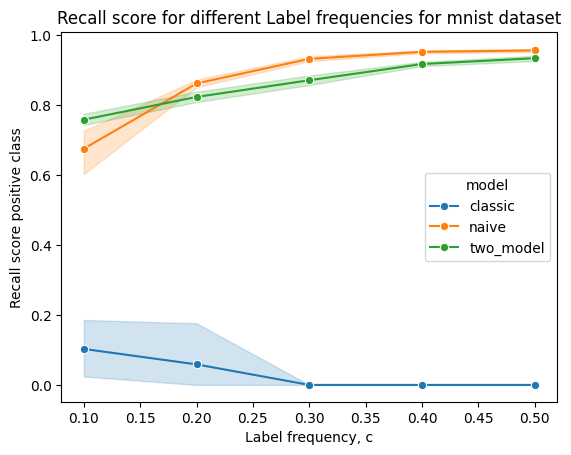

In [88]:
for name,data in zip(datasets,[mock,diabetes,breastcancer,mnist]):
    plt.figure()
    sns.lineplot(data=data, x="c", y="1 recall", hue="model", marker="o")
    plt.title(f"Recall score for different Label frequencies for {name} dataset")
    plt.ylabel(r"Recall score positive class")
    plt.xlabel("Label frequency, c")
    plt.savefig(f"graphs/c_{name}_recall.png")

    # sns.lineplot(data=data, x="c", y="1 precision", hue="model", marker="o", linestyle="--")
    # sns.lineplot(data=data, x="c", y="1 recall", hue="model", marker="o", linestyle=":")
